<a href="https://colab.research.google.com/github/volodymyr-holovan/melbourne-housing-snapshot/blob/main/Analysis/melbourne_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Melbourne Housing Price Prediction

End-to-end regression pipeline: cleaning, EDA, feature engineering, modeling, evaluation.

- **Dataset:** Melbourne Housing Snapshot (`melb_data.csv`)
- **Target:** `Price`
- **Task type:** regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 30)

## Step 1. Load data

In [3]:
RAW_URL = "https://raw.githubusercontent.com/volodymyr-holovan/melbourne-housing-snapshot/refs/heads/main/Data/melb_data.csv"
df = pd.read_csv(RAW_URL)

print(df.shape)
df.head()

(13580, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


## Step 2. Initial overview

In [4]:
df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,float64


In [5]:
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
missing_pct[missing_pct > 0]

,0
BuildingArea,47.50
YearBuilt,39.58
CouncilArea,10.08
Car,0.46


In [6]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


**Observations:**
- `BuildingArea` (48%) and `YearBuilt` (40%) have high missing rates; `CouncilArea` is missing in 10% of rows.
- `YearBuilt` minimum is 1196 - a data entry error, not a real construction year.
- `Date` is read as text (`object`), not as a date type.
- No unexpected technical index column in this file.

## Step 3. Cleaning

In [7]:
clean = df.copy()

# drop technical index column, if present
unnamed_cols = [c for c in clean.columns if c.lower().startswith("unnamed")]
clean = clean.drop(columns=unnamed_cols)

# Date: text -> datetime, day-first format
clean["Date"] = pd.to_datetime(clean["Date"], dayfirst=True)

# zero area is not a real value here -> treat as missing
for col in ["Landsize", "BuildingArea"]:
    clean.loc[clean[col] == 0, col] = np.nan

# implausible construction year -> missing
MIN_YEAR = 1800
clean.loc[clean["YearBuilt"] < MIN_YEAR, "YearBuilt"] = np.nan

# duplicate rows
dup_count = clean.duplicated().sum()
print("duplicate rows:", dup_count)
clean = clean.drop_duplicates()

clean.shape

duplicate rows: 0


(13580, 21)

## Step 4. Exploratory data analysis (EDA)

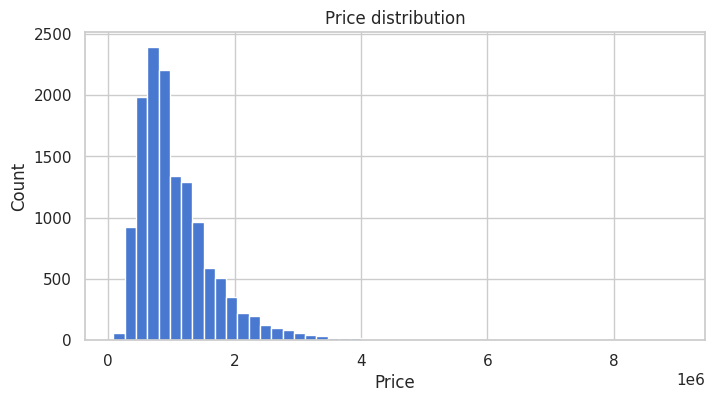

In [8]:
plt.figure(figsize=(8, 4))
plt.hist(clean["Price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price distribution")
plt.show()

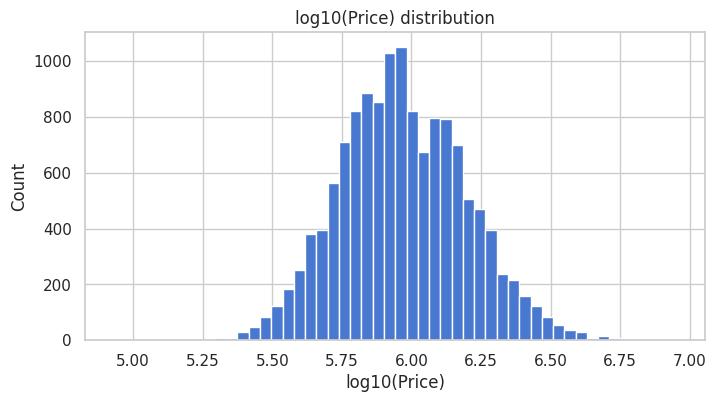

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(np.log10(clean["Price"]), bins=50)
plt.xlabel("log10(Price)")
plt.ylabel("Count")
plt.title("log10(Price) distribution")
plt.show()

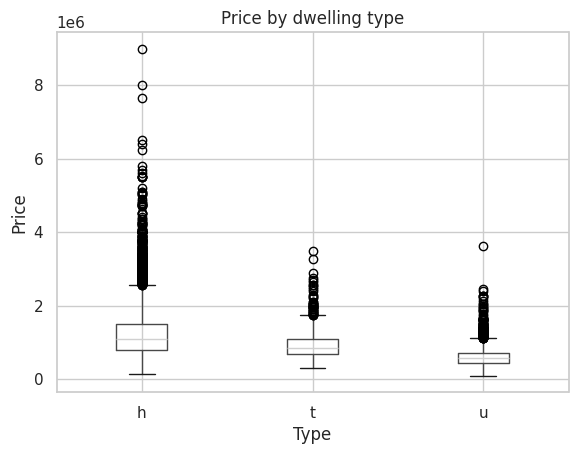

In [10]:
clean.boxplot(column="Price", by="Type")
plt.title("Price by dwelling type")
plt.suptitle("")
plt.ylabel("Price")
plt.show()

In [11]:
num = clean.select_dtypes("number")
corr_price = num.corr()["Price"].drop("Price").sort_values(key=abs, ascending=False)
corr_price

,Price
Rooms,0.496634
Bedroom2,0.475951
Bathroom,0.467038
YearBuilt,-0.331828
Car,0.238979
Lattitude,-0.212934
Longtitude,0.203656
Distance,-0.162522
Postcode,0.107867
BuildingArea,0.091576


In [12]:
full_corr = num.corr().round(2)
full_corr.loc[["Rooms", "Bedroom2"], ["Rooms", "Bedroom2"]]

,Rooms,Bedroom2
Rooms,1.00,0.94
Bedroom2,0.94,1.00


**Findings:**
- `Price` is right-skewed; the log10 transform gives a near-symmetric distribution.
- Median price by dwelling type: house (`h`) 1,080,000, townhouse (`t`) 846,750, unit (`u`) 560,000.
- Strongest linear correlations with `Price`: `Rooms` (0.50), `Bedroom2` (0.48), `Bathroom` (0.47), `YearBuilt` (-0.33), `Distance` (-0.16).
- `Rooms` and `Bedroom2` correlate at 0.94 - near-duplicate features; only one is needed.

## Step 5. Feature engineering

In [13]:
fe = clean.copy()

# date parts
fe["sale_year"] = fe["Date"].dt.year
fe["sale_month"] = fe["Date"].dt.month

# building age at time of sale, guard against negative values
fe["building_age"] = fe["sale_year"] - fe["YearBuilt"]
fe.loc[fe["building_age"] < 0, "building_age"] = np.nan

# missingness flags: the fact of a missing value can itself be informative
fe["has_buildingarea"] = fe["BuildingArea"].notna().astype(int)
fe["has_yearbuilt"] = fe["YearBuilt"].notna().astype(int)

# frequency encoding for high-cardinality Suburb
fe["suburb_freq"] = fe["Suburb"].map(fe["Suburb"].value_counts())

# drop redundant/unusable columns:
# Bedroom2 duplicates Rooms; Address/SellerG/Suburb are raw high-cardinality text; Date is already split into parts
fe = fe.drop(columns=["Bedroom2", "Address", "SellerG", "Suburb", "Date"])

fe.shape

(13580, 22)

## Step 6. Modeling preparation

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

y = fe["Price"]
X = fe.drop(columns=["Price"])

cat_cols = ["Type", "Method", "Regionname", "CouncilArea"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train.shape, X_test.shape

((10864, 21), (2716, 21))

## Step 7. Models and prediction

In [16]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(model, name):
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)
    print(f"{name}: MAE={mae:,.0f}  RMSE={rmse:,.0f}  R2={r2:.3f}")
    return pipe

pipe_dummy = evaluate(DummyRegressor(strategy="mean"), "Baseline (mean)")
pipe_lr = evaluate(LinearRegression(), "Linear Regression")
pipe_rf = evaluate(RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), "Random Forest")

Baseline (mean): MAE=461,258  RMSE=630,259  R2=-0.000
Linear Regression: MAE=256,130  RMSE=372,664  R2=0.650
Random Forest: MAE=162,919  RMSE=269,667  R2=0.817


In [17]:
rf_model = pipe_rf.named_steps["model"]
feat_names = pipe_rf.named_steps["prep"].get_feature_names_out()

importances = pd.Series(rf_model.feature_importances_, index=feat_names).sort_values(ascending=False)
importances.head(15)

,0
cat__Regionname_Southern Metropolitan,0.208611
num__Rooms,0.174061
num__Distance,0.136209
cat__Type_u,0.088965
num__Landsize,0.078228
num__Longtitude,0.052484
num__BuildingArea,0.046065
num__Lattitude,0.041851
num__Bathroom,0.030412
num__Propertycount,0.016817


In [18]:
example = X_test.iloc[[0]]
predicted = pipe_rf.predict(example)[0]
actual = y_test.iloc[0]

print(f"predicted: {predicted:,.0f}")
print(f"actual: {actual:,.0f}")

predicted: 2,153,792
actual: 2,600,000


## Conclusions

- Random Forest is the best-performing model: MAE ≈ 163,000, RMSE ≈ 270,000, R2 ≈ 0.82, versus R2 ≈ 0.65 for Linear Regression and R2 ≈ 0.00 for the baseline.
- Top price drivers by Random Forest feature importance: region (`Southern Metropolitan`), `Rooms`, `Distance` to CBD, dwelling type `unit`, `Landsize`.
- Further improvement options: hyperparameter tuning (`GridSearchCV` / `RandomizedSearchCV`) for Random Forest; gradient boosting models (XGBoost / LightGBM / CatBoost); geospatial features derived from `Lattitude` / `Longtitude` (e.g. distance to CBD center, location clustering).